In [1]:
import pandas as pd
from dotenv import load_dotenv

from pronostico_demanda_electrica.storage import crear_engine

load_dotenv()
engine = crear_engine()
pd.read_sql("SELECT COUNT(*) AS filas FROM demanda_horaria", engine)

,filas
0,368063


In [2]:
from pronostico_demanda_electrica.queries import leer_demanda_mensual

mensual = leer_demanda_mensual(engine)
mensual.shape

(504, 6)

In [3]:
mensual["gwh_dia"] = mensual["demanda_gwh"] / mensual["dias"]
mensual.head()

,mes,sistema,area,demanda_gwh,region,dias,gwh_dia
0,2022-01-01,BCA,BCA,1079.523837,BCA-BCA,31,34.823350
1,2022-02-01,BCA,BCA,992.446796,BCA-BCA,28,35.444528
2,2022-03-01,BCA,BCA,1112.224152,BCA-BCA,31,35.878198
3,2022-04-01,BCA,BCA,1149.081892,BCA-BCA,30,38.302730
4,2022-05-01,BCA,BCA,1351.901561,BCA-BCA,31,43.609728


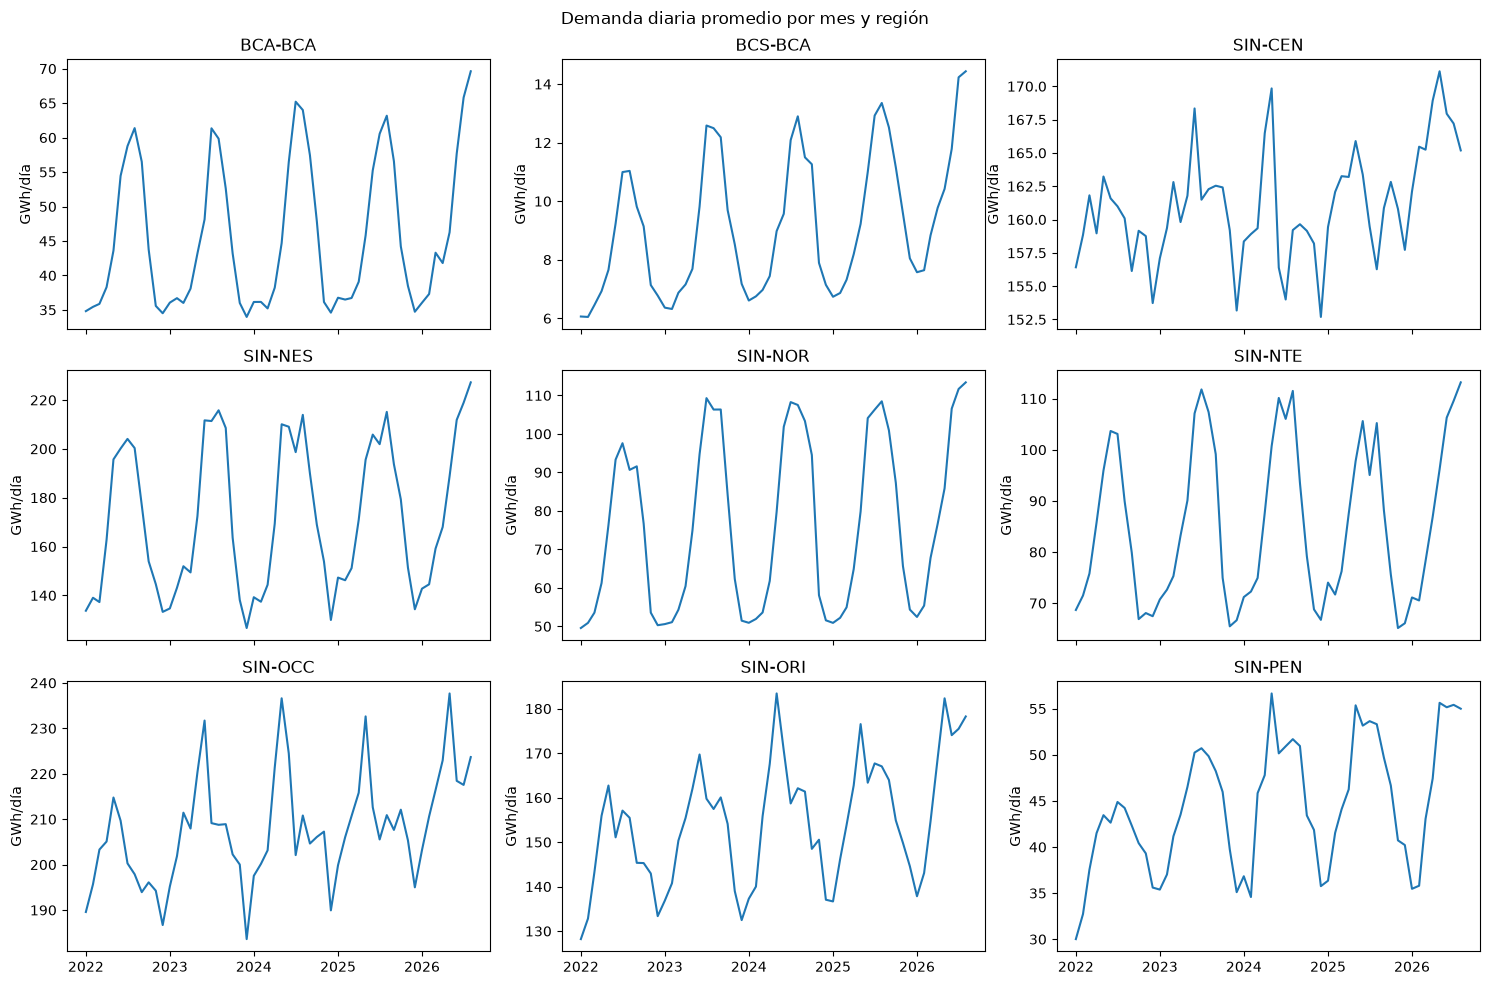

In [4]:
import matplotlib.pyplot as plt

fig, ejes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
for eje, (region, datos) in zip(ejes.flat, mensual.groupby("region")):
    eje.plot(datos["mes"], datos["gwh_dia"])
    eje.set_title(region)
    eje.set_ylabel("GWh/día")
fig.suptitle("Demanda diaria promedio por mes y región")
fig.tight_layout()

In [5]:
ytd = mensual[
    (mensual["mes"].dt.month <= 8) & (mensual["mes"].dt.year.isin([2025, 2026]))
]
crecimiento = ytd.pivot_table(
    index="region", columns=ytd["mes"].dt.year, values="demanda_gwh", aggfunc="sum"
)
crecimiento["crecimiento_%"] = (crecimiento[2026] / crecimiento[2025] - 1) * 100
crecimiento.sort_values("crecimiento_%", ascending=False).round(1)

mes,2025,2026,crecimiento_%
region,,,
BCS-BCA,2304.1,2581.3,12.0
SIN-NOR,18946.7,20413.8,7.7
BCA-BCA,11386.0,12121.5,6.5
SIN-OCC,51471.4,53193.1,3.3
SIN-ORI,38733.2,39982.5,3.2
SIN-CEN,39269.5,40495.9,3.1
SIN-NTE,21698.0,22286.2,2.7
SIN-NES,43641.6,44486.9,1.9
SIN-PEN,11672.0,11662.6,-0.1


In [6]:
ene_ago = mensual[mensual["mes"].dt.month <= 8]
anual = ene_ago.pivot_table(
    index="region", columns=ene_ago["mes"].dt.year, values="demanda_gwh", aggfunc="sum"
)
(anual.pct_change(axis=1) * 100).round(1)

mes,2022,2023,2024,2025,2026
region,,,,,
BCA-BCA,NaN,-0.9,5.0,-0.9,6.5
BCS-BCA,NaN,7.6,3.2,5.7,12.0
SIN-CEN,NaN,0.9,-0.4,0.4,3.1
SIN-NES,NaN,1.3,2.6,0.5,1.9
SIN-NOR,NaN,5.1,2.6,0.7,7.7
SIN-NTE,NaN,3.5,2.6,-3.2,2.7
SIN-OCC,NaN,4.3,1.0,-0.5,3.3
SIN-ORI,NaN,3.8,3.9,-0.5,3.2
SIN-PEN,NaN,11.8,6.1,2.0,-0.1


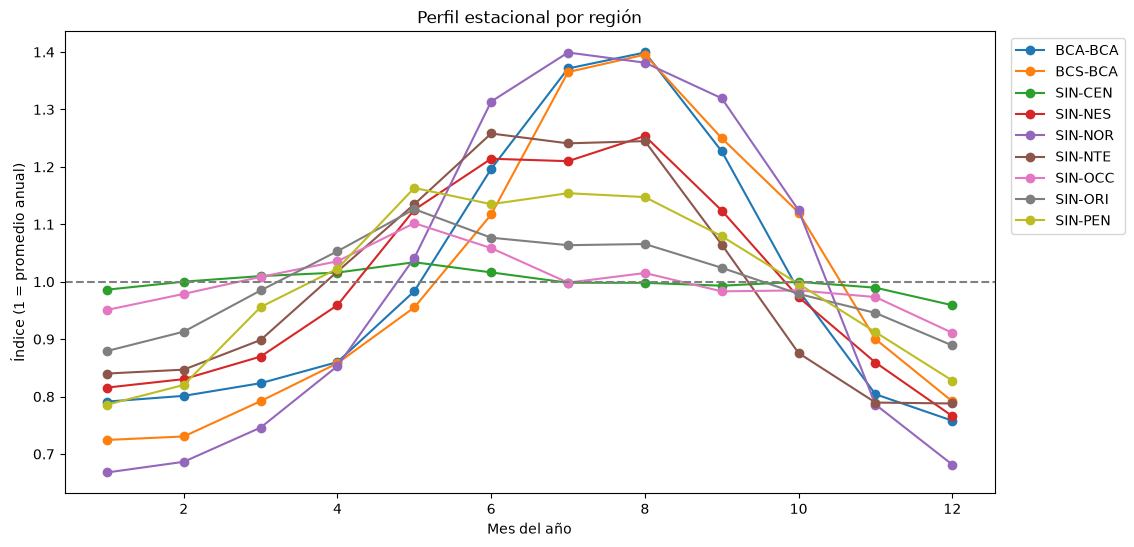

In [7]:
perfil = (
    mensual.groupby(["region", mensual["mes"].dt.month])["gwh_dia"]
    .mean()
    .unstack(level=0)
)
indice = perfil / perfil.mean()

ax = indice.plot(figsize=(12, 6), marker="o")
ax.axhline(1, color="gray", linestyle="--")
ax.set_xlabel("Mes del año")
ax.set_ylabel("Índice (1 = promedio anual)")
ax.set_title("Perfil estacional por región")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")

In [8]:
peso = (
    mensual[mensual["mes"].dt.year == 2025]
    .groupby("region")["demanda_gwh"]
    .sum()
    .sort_values(ascending=False)
)
(peso / peso.sum() * 100).round(1)

region
SIN-OCC    21.7
SIN-NES    18.1
SIN-CEN    16.7
SIN-ORI    16.3
SIN-NTE     8.7
SIN-NOR     8.0
SIN-PEN     4.8
BCA-BCA     4.7
BCS-BCA     1.0
Name: demanda_gwh, dtype: float64

In [9]:
mensual = mensual.sort_values(["region", "mes"])
mensual["var_anual_%"] = mensual.groupby("region")["gwh_dia"].pct_change(12) * 100

atipicos = mensual[mensual["var_anual_%"].abs() > 10]
atipicos[["region", "mes", "gwh_dia", "var_anual_%"]].round(1)

/tmp/ipykernel_58049/903776092.py:5: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  atipicos[["region", "mes", "gwh_dia", "var_anual_%"]].round(1)


,region,mes,gwh_dia,var_anual_%
17,BCA-BCA,2023-06-01,48.1,-11.6
29,BCA-BCA,2024-06-01,56.5,17.3
33,BCA-BCA,2024-10-01,47.9,10.8
50,BCA-BCA,2026-03-01,43.3,17.9
55,BCA-BCA,2026-08-01,69.6,10.2
74,BCS-BCA,2023-07-01,12.6,14.5
75,BCS-BCA,2023-08-01,12.5,13.2
76,BCS-BCA,2023-09-01,12.2,24.1
78,BCS-BCA,2023-11-01,8.5,19.5
84,BCS-BCA,2024-05-01,9.0,16.8
